In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions

from src.diffeomorphisms.vector.nflow import NFlowVectorDiffeomorphism
from src.diffeomorphisms.vector.poincare import PoincareVectorDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.vector.l2_tangent_space_pca import l2TangentSpacePCAVectorSolver
from src.manifolds.euclidean.vector.pullback.hyperbolic import HyperbolicdPullbackVectorEuclidean
from src.manifolds.hyperbolic.vector.standard import StandardVectorHyperbolic
from src.riemannian_autoencoder.vector.k_fold import KfoldVectorRiemannianAutoencoder
from src.riemannian_autoencoder.vector.standard import StandardVectorRiemannianAutoencoder
from src.transforms.parity.tanh import TanhParityTransform
from src.transforms.householder_linear import HouseholderLinearTransform

# fix seed
torch.manual_seed(31)

### Construct data set ###

Data shape: torch.Size([2000, 3])


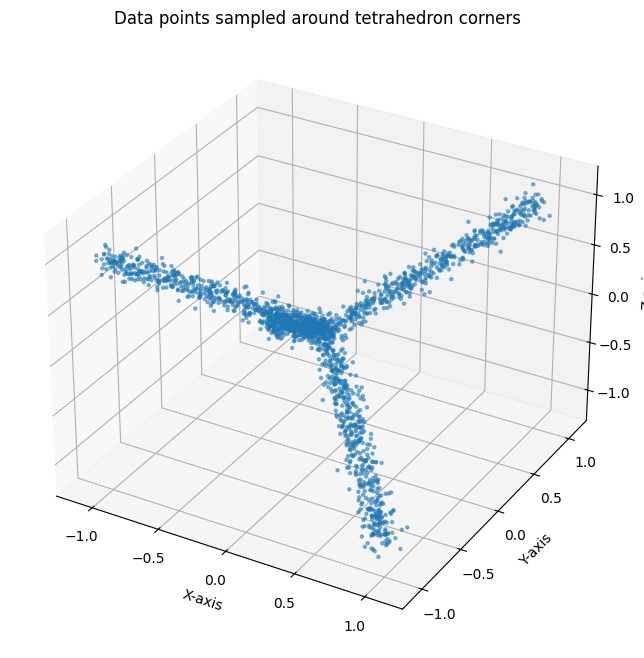

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += 0.05 * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)
print("Data shape:", data.shape)

# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
ax.set_title("Data points sampled around tetrahedron corners")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.show()

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.shape[0]

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime = self.data[idx2]
        return x, x_prime
    
# create dataset and dataloader
pair_dataset = RandomPairDataset(data)
dataloader = DataLoader(pair_dataset, batch_size=128, shuffle=True)

### Embed data set ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
# construct neural network architecture
class SimpleNN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = torch.nn.Linear(input_dim, hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = torch.nn.Linear(hidden_dim, hidden_dim)
        self.fc4 = torch.nn.Linear(hidden_dim, output_dim)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x
    
# instantiate the neural network
input_dim = 3
hidden_dim = 20
output_dim = 2  # we will embed into 2D hyperbolic space
nn_model = SimpleNN(input_dim, hidden_dim, output_dim)

# construct Gromov-Monge Embedding with poincare map
class HyperbolicGromovMongeEmbedding(torch.nn.Module):
    def __init__(self, nn_model, output_dim=2):
        super(HyperbolicGromovMongeEmbedding, self).__init__()
        self.nn_model = nn_model
        self.poincare_map = PoincareVectorDiffeomorphism(output_dim)
        self.manifold = StandardVectorHyperbolic(output_dim)
        self.origin = None
        self.d = self.manifold.d

    def forward(self, x):
        """
        
        :param x: N x d
        :return: N x output_dim
        """
        nn_output = self.nn_model(x)
        hyperbolic_embedding = self.poincare_map(nn_output)
        if self.origin is not None:
            hyperbolic_embedding = self.translate(hyperbolic_embedding, self.origin)
        return hyperbolic_embedding
    
    def set_origin(self, origin):
        """
        
        :param origin: output_dim 
        """
        self.origin = origin

    def translate(self, z, translation):
        """
        
        :param z: N x output_dim
        :param translation: output_dim
        :return: N x output_dim
        """
        norm_tr_sq = torch.sum(translation**2)
        norm_x_sq = torch.sum(z**2, dim=-1)
        xtr_dot = torch.sum(z * translation.unsqueeze(0), dim=-1)
        numerator = (1 - norm_tr_sq) * z - (1 - 2 * xtr_dot.unsqueeze(-1) + norm_x_sq.unsqueeze(-1)) * translation.unsqueeze(0)
        denominator = 1 - 2 * xtr_dot + norm_tr_sq * norm_x_sq
        return numerator / denominator.unsqueeze(-1)

    def distance(self, x1, x2):
        """
        
        :param x1: N x d
        :param x2: N x d
        :return: N
        """
        emb1 = self.forward(x1)
        emb2 = self.forward(x2)
        dist = self.manifold.distance(emb1.unsqueeze(1), emb2.unsqueeze(1)).squeeze(2).squeeze(1)
        return dist
    
    def interpolate(self, x1, x2, t):
        """
        
        :param x1: N x d
        :param x2: N x d
        :param t: K
        :return: N x K x output_dim
        """
        emb1 = self.forward(x1)
        emb2 = self.forward(x2)
        interp_emb = self.manifold.geodesic(emb1.unsqueeze(1), emb2.unsqueeze(1), t).squeeze(2).squeeze(1)
        return interp_emb
    
    def barycentre(self, x):
        """
        
        :param x: N x d
        :return: output_dim
        """
        emb_points = self.forward(x)
        barycentre = self.manifold.barycentre(emb_points)
        return barycentre

# instantiate Gromov-Monge Embedding
T = HyperbolicGromovMongeEmbedding(nn_model, output_dim=2)

In [5]:
# construct train loop
optimizer = torch.optim.Adam(T.nn_model.parameters(), lr=0.001)
num_epochs = 50
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for x, x_prime in dataloader:
        optimizer.zero_grad()
        dist_data = torch.norm(x - x_prime, dim=1)
        dist_emb = T.distance(x, x_prime)
        loss = torch.log((1 + dist_emb ** 2) / (1 + dist_data ** 2)).pow(2).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.6f}")


Epoch 1/50, Loss: 1.107273
Epoch 2/50, Loss: 0.752215
Epoch 3/50, Loss: 0.345244
Epoch 4/50, Loss: 0.165422
Epoch 5/50, Loss: 0.143872
Epoch 6/50, Loss: 0.129077
Epoch 7/50, Loss: 0.099330
Epoch 8/50, Loss: 0.059735
Epoch 9/50, Loss: 0.029030
Epoch 10/50, Loss: 0.020816
Epoch 11/50, Loss: 0.019457
Epoch 12/50, Loss: 0.019209
Epoch 13/50, Loss: 0.018099
Epoch 14/50, Loss: 0.017593
Epoch 15/50, Loss: 0.017718
Epoch 16/50, Loss: 0.016885
Epoch 17/50, Loss: 0.017527
Epoch 18/50, Loss: 0.016676
Epoch 19/50, Loss: 0.017826
Epoch 20/50, Loss: 0.016732
Epoch 21/50, Loss: 0.018025
Epoch 22/50, Loss: 0.016298
Epoch 23/50, Loss: 0.017672
Epoch 24/50, Loss: 0.017871
Epoch 25/50, Loss: 0.017796
Epoch 26/50, Loss: 0.016530
Epoch 27/50, Loss: 0.016891
Epoch 28/50, Loss: 0.017552
Epoch 29/50, Loss: 0.017316
Epoch 30/50, Loss: 0.016688
Epoch 31/50, Loss: 0.016130
Epoch 32/50, Loss: 0.016876
Epoch 33/50, Loss: 0.017156
Epoch 34/50, Loss: 0.017912
Epoch 35/50, Loss: 0.016943
Epoch 36/50, Loss: 0.016601
E

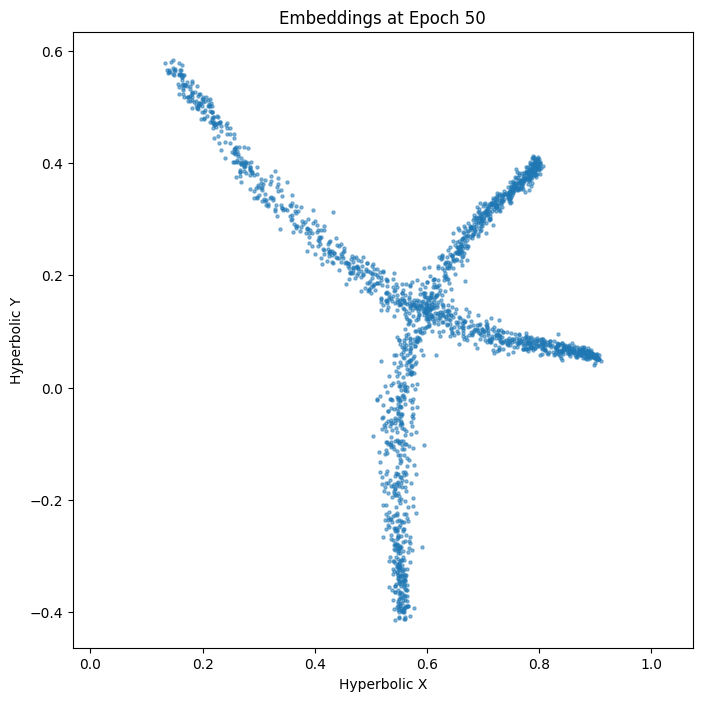

In [6]:
# visualize embeddings
with torch.no_grad():
    embeddings = T(data).cpu().numpy()
plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.title(f"Embeddings at Epoch {epoch+1}")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

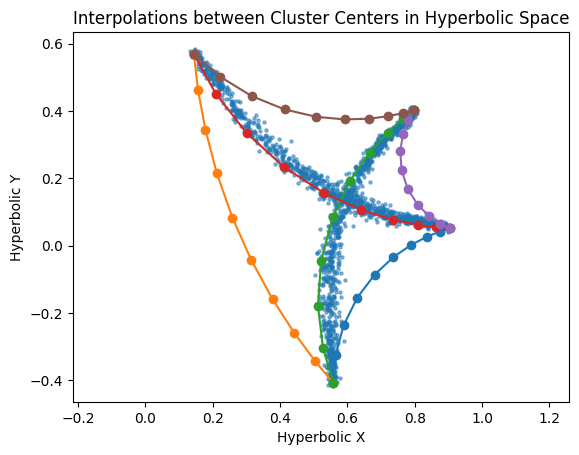

In [7]:
# interpolate between cluster centers
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]):
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points = T.interpolate(center1, center2, t_values)[0]
        # interp_points = interp_points.cpu().numpy()
        plt.plot(interp_points[:, 0], interp_points[:, 1], marker='o')
plt.title("Interpolations between Cluster Centers in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

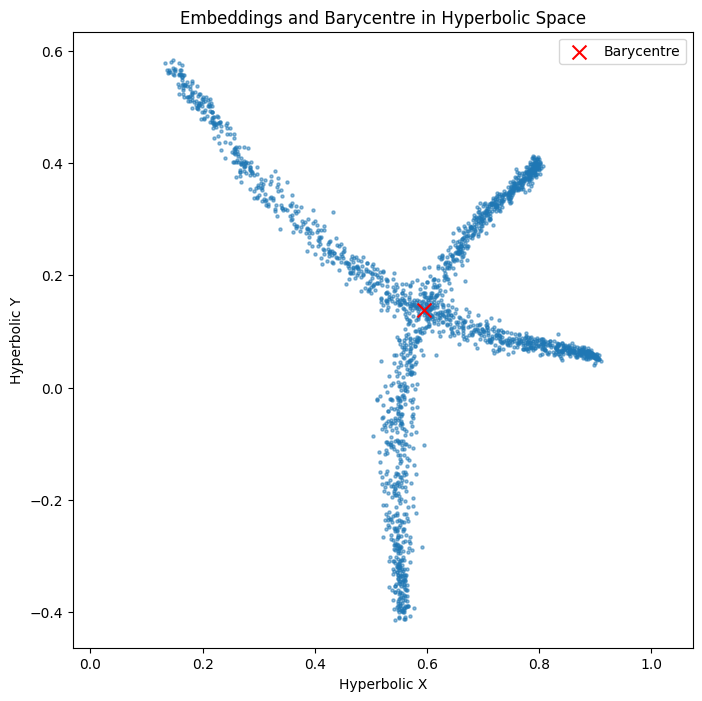

In [8]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre = T.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings[:, 0], embeddings[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.show()  

In [9]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = T.distance(data_clusters[1:], data_clusters[:-1])

# update origin
T.set_origin(barycentre)

# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = T.distance(data_clusters[1:], data_clusters[:-1])

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero

Pairwise distance matrix in embedding space between cluster centers:
tensor(1.9073e-06)


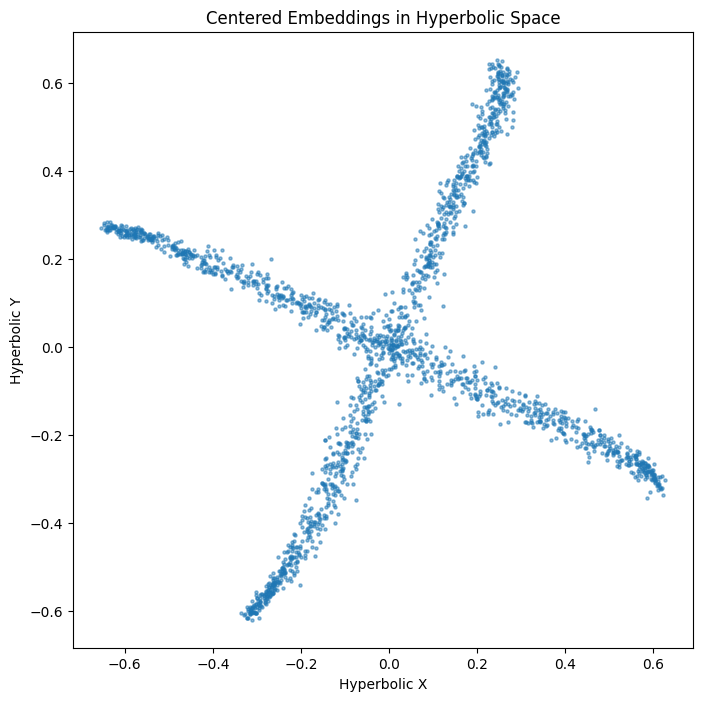

In [10]:
# compute embeddings again after centering
with torch.no_grad():
    embeddings_centered = T(data)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.title("Centered Embeddings in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

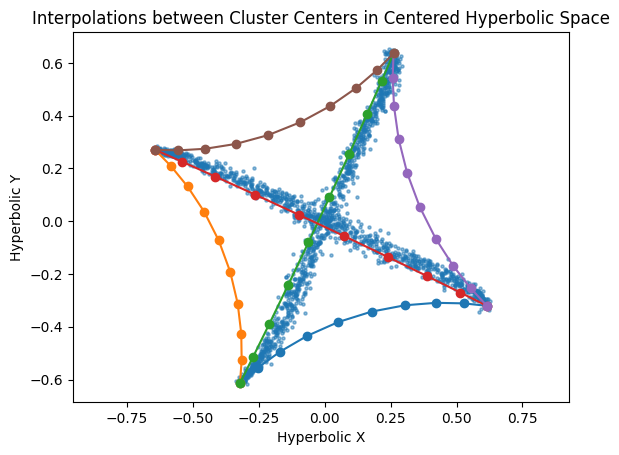

In [11]:
# interpolate between cluster centers after centering
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        center1 = data_clusters[i].unsqueeze(0)
        center2 = data_clusters[j].unsqueeze(0)
        t_values = torch.linspace(0, 1, steps=10)
        with torch.no_grad():
            interp_points_centered = T.interpolate(center1, center2, t_values)[0]
        plt.plot(interp_points_centered[:, 0], interp_points_centered[:, 1], marker='o')
plt.title("Interpolations between Cluster Centers in Centered Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.show()

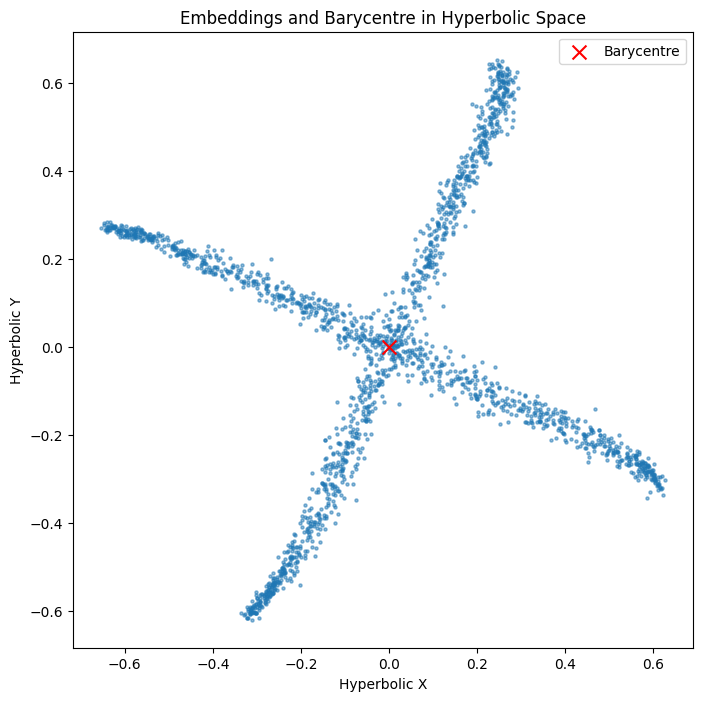

Distance between barycentres before and after centering:
2.437876901240088e-06


In [12]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    barycentre_centered = T.barycentre(data)

plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5)
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = T.translate(barycentre, barycentre)
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

### Learn embedding-informed pullback geometry ###

In [13]:
# construct normalizing flow model
class SimpleNFlowVectorDiffeomorphism(NFlowVectorDiffeomorphism):
    def __init__(self, dim, n_flows, n_hoho, order):
        super(SimpleNFlowVectorDiffeomorphism, self).__init__(dim, self.create_flow_model(dim, n_flows, n_hoho, order))

    def create_flow_model(self, dim, n_flows, n_hoho, order):
        base_dist = distributions.StandardNormal(shape=[dim])
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(transforms.normalization.ActNorm(features=dim))
            for _ in range(n_hoho):
                transforms_list.append(HouseholderLinearTransform(dim))
            transforms_list.append(TanhParityTransform(dim, order, parity=i%2))
        flow_transforms = transforms.CompositeTransform(transforms_list)
        return flows.Flow(transform=flow_transforms, distribution=base_dist)

# instantiate flow model
dim = 3
n_flows = 2
n_hoho = 2
order = 2
phi = SimpleNFlowVectorDiffeomorphism(dim, n_flows, n_hoho, order)

# class for training the embedding-informed normalizing flow
class HyperbolicGromovMongeEmbeddingInformedNFlowTraining(torch.nn.Module):
    def __init__(self, embedding_model, nflow_diffeomorphism, reg_param=None):
        super(HyperbolicGromovMongeEmbeddingInformedNFlowTraining, self).__init__()
        self.emb = embedding_model # embedding model into hyperbolic space
        self.phi = nflow_diffeomorphism # normalizing flow model into Euclidean space
        self.reg_param = reg_param
        self.W = torch.nn.Parameter(torch.randn(self.emb.d, self.phi.d))

    def loss(self, x):
        """
        
        :param x: N x d
        :return: scalar loss
        """
        
        # reconstruction loss
        emb_x = self.emb(x)  # N x emb.d
        log_0_emb_x = self.emb.poincare_map.inverse(emb_x)  # N x emb.d
        p_x = log_0_emb_x @ self.W  # N x d
        phi_inv_p_x = self.phi.inverse(p_x.reshape(x.shape))  # N x d
        recon_loss = torch.nn.functional.mse_loss(phi_inv_p_x, x, reduction='mean')

        # total loss
        if self.reg_param is None:
            loss = recon_loss
        else:
            # negative log likelihood loss
            log_prob = self.phi.nflow.log_prob(x)  # N
            neg_log_prob_loss = -log_prob.mean()
            
            loss = recon_loss + self.reg_param * neg_log_prob_loss
        return loss
    
# instantiate HGME-informed normalizing flow
reg_param = 0.01
hgme_nflow = HyperbolicGromovMongeEmbeddingInformedNFlowTraining(T, phi, reg_param=reg_param)

# freeze embedding model parameters
for param in hgme_nflow.emb.parameters():
    param.requires_grad = False

In [14]:
# construct train loop
optimizer_hgme_nflow = torch.optim.Adam(list(hgme_nflow.phi.nflow.parameters()) + [hgme_nflow.W], lr=0.005) 
num_epochs_flow = 250
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for x, _ in dataloader:
        optimizer_hgme_nflow.zero_grad()
        loss = hgme_nflow.loss(x)
        loss.backward()
        optimizer_hgme_nflow.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(pair_dataset)
    print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

Flow Epoch 1/250, Loss: 0.524352
Flow Epoch 2/250, Loss: 0.423196
Flow Epoch 3/250, Loss: 0.350753
Flow Epoch 4/250, Loss: 0.281150
Flow Epoch 5/250, Loss: 0.223784
Flow Epoch 6/250, Loss: 0.183983
Flow Epoch 7/250, Loss: 0.160033
Flow Epoch 8/250, Loss: 0.150570
Flow Epoch 9/250, Loss: 0.146455
Flow Epoch 10/250, Loss: 0.143189
Flow Epoch 11/250, Loss: 0.137765
Flow Epoch 12/250, Loss: 0.128986
Flow Epoch 13/250, Loss: 0.114276
Flow Epoch 14/250, Loss: 0.093860
Flow Epoch 15/250, Loss: 0.074920
Flow Epoch 16/250, Loss: 0.066121
Flow Epoch 17/250, Loss: 0.060877
Flow Epoch 18/250, Loss: 0.056892
Flow Epoch 19/250, Loss: 0.054629
Flow Epoch 20/250, Loss: 0.052966
Flow Epoch 21/250, Loss: 0.051818
Flow Epoch 22/250, Loss: 0.050616
Flow Epoch 23/250, Loss: 0.049508
Flow Epoch 24/250, Loss: 0.048497
Flow Epoch 25/250, Loss: 0.047438
Flow Epoch 26/250, Loss: 0.046450
Flow Epoch 27/250, Loss: 0.045572
Flow Epoch 28/250, Loss: 0.044523
Flow Epoch 29/250, Loss: 0.043474
Flow Epoch 30/250, Loss

In [15]:
# construct manifold from learned flow
manifold = HyperbolicdPullbackVectorEuclidean(hgme_nflow.phi)

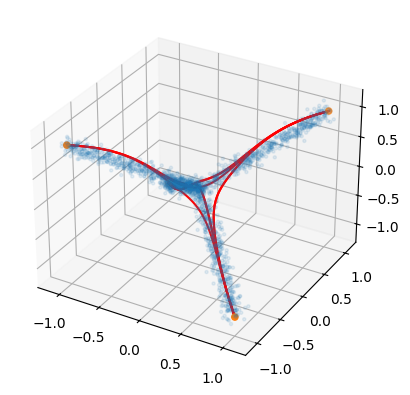

In [16]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    geodesics = manifold.geodesic(data_clusters[None], data_clusters[None], t)

# plot geodesics
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(geodesics.shape[1]):
    for j in range(geodesics.shape[2]-1):
        ax.plot(geodesics[0, i, j, :, 0].numpy(), geodesics[0, i, j, :, 1].numpy(), geodesics[0, i, j, :, 2].numpy(), 'r-')
ax.scatter(data_clusters[:, 0].numpy(), data_clusters[:, 1].numpy(), data_clusters[:, 2].numpy())
plt.show()

In [17]:
# sanity check: is the embedding still the same (and was not accidentally changed during flow training)
with torch.no_grad():
    embeddings_after_flow = hgme_nflow.emb(data)
print("Max difference in embeddings before and after flow training:", (embeddings_after_flow - embeddings_centered).abs().max().item())  # should be close to zero

Max difference in embeddings before and after flow training: 0.0


Computing rank 2 approximation on tangent space
Computing rank 2 approximation on euclidean space
Computing rank 2 errors


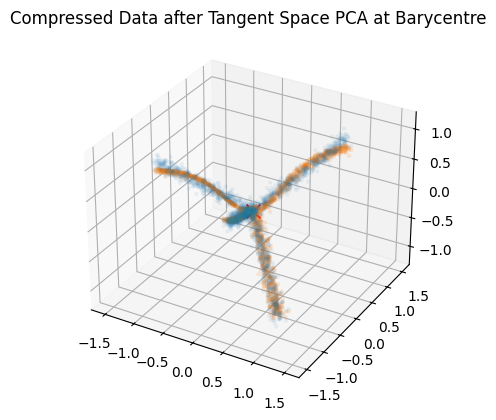

Mean reconstruction error after RAE compression: 0.07326821982860565


In [18]:
# compute data barycentre
barycentre_data = manifold.barycentre(data, tol=1e-5, max_iter=100, step_size=0.5, red_coef=None)
# tangent space PCA to find principal directions at data barycentre
l2_pga_solver_bary = l2TangentSpacePCAVectorSolver(data, manifold, barycentre_data)
# compute principal directions
_, compressed_data, _ = l2_pga_solver_bary.solve(2)

# plot compressed data in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(compressed_data[:, 0].numpy(), compressed_data[:, 1].numpy(), compressed_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Compressed Data after Tangent Space PCA at Barycentre")
plt.axis('equal')
plt.show()

# compute error between original data and compressed data
rel_error = (torch.norm(data - compressed_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after RAE compression:", rel_error)

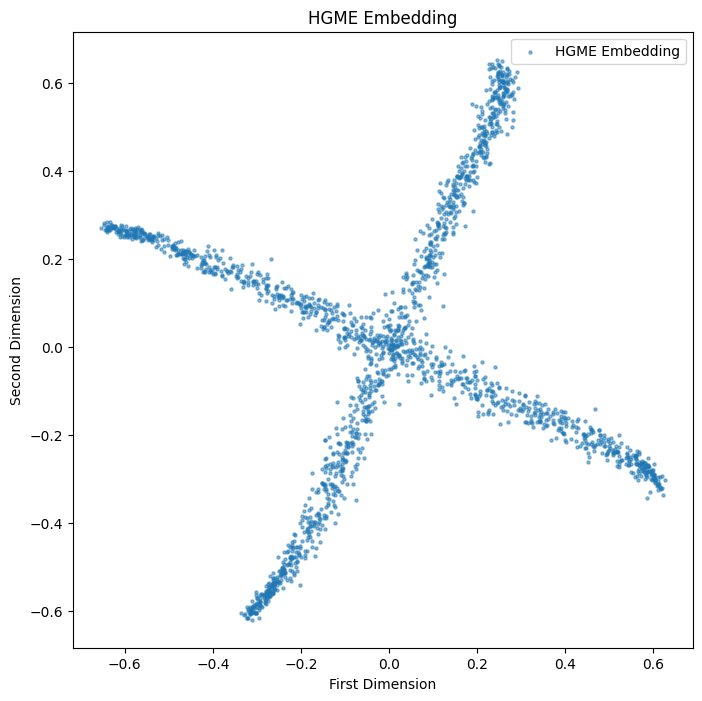

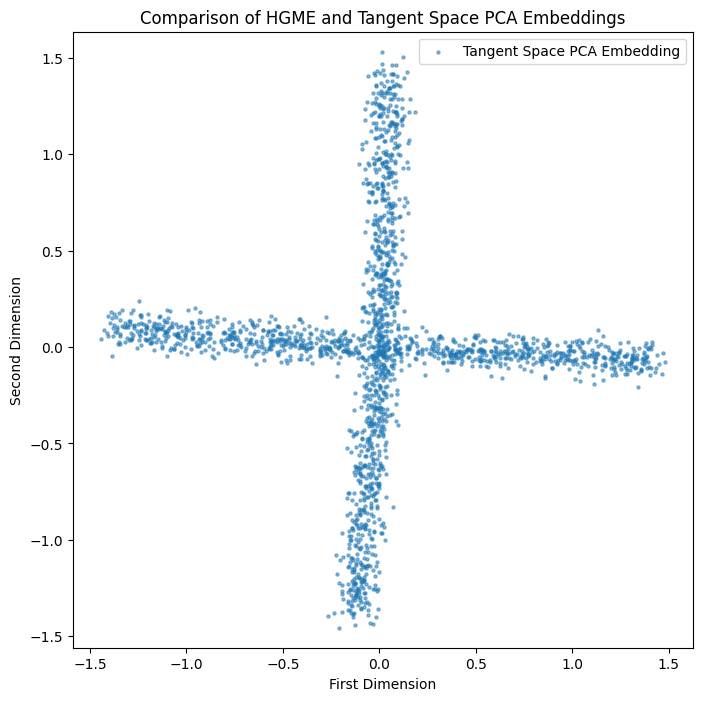

In [19]:
# compare embeddings
pca_embedding = l2_pga_solver_bary.get_embedding(2)

# plot embeddings comparison in different figures (because different spaces)
plt.figure(figsize=(8, 8))
plt.scatter(embeddings_centered[:, 0], embeddings_centered[:, 1], s=5, alpha=0.5, label='HGME Embedding')
plt.title("HGME Embedding")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(pca_embedding[:, 0], pca_embedding[:, 1], s=5, alpha=0.5, label='Tangent Space PCA Embedding')
plt.title("Comparison of HGME and Tangent Space PCA Embeddings")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.legend()    
plt.axis('equal')
plt.show()

Tangent basis vectors at barycentre:
tensor([[-0.7476, -0.6625, -0.0468],
        [-0.6633,  0.7483,  0.0032]])
Inner products between tangent basis vectors (should be close to identity):
tensor([[1.0000e+00, 8.9911e-08],
        [8.9911e-08, 1.0000e+00]])


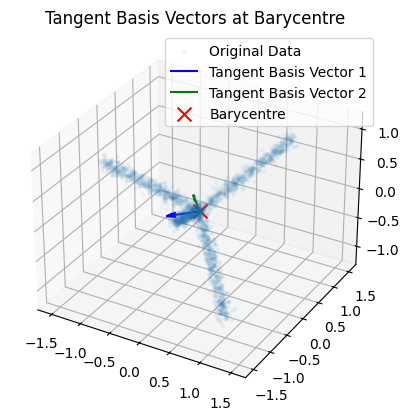

In [20]:
# get tangent basis
tangent_basis_barycentre_data = l2_pga_solver_bary.get_tangent_basis(2)
print("Tangent basis vectors at barycentre:")
print(tangent_basis_barycentre_data)
# make sure they are orthonormal
print("Inner products between tangent basis vectors (should be close to identity):")
print(tangent_basis_barycentre_data @ tangent_basis_barycentre_data.t())

# plot tangent basis vectors at barycentre in 3D with data points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')  
# plot tangent basis vectors through quiver plot
ax.quiver(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(),
          tangent_basis_barycentre_data[0, 0].item(), tangent_basis_barycentre_data[0, 1].item(), tangent_basis_barycentre_data[0, 2].item(),
          length=0.5, color='blue', label='Tangent Basis Vector 1')
ax.quiver(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(),
          tangent_basis_barycentre_data[1, 0].item(), tangent_basis_barycentre_data[1, 1].item(), tangent_basis_barycentre_data[1, 2].item(),
          length=0.5, color='green', label='Tangent Basis Vector 2')    
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Tangent Basis Vectors at Barycentre")
plt.axis('equal')
plt.legend()
plt.show()

In [21]:
# construct RAE
s_rae = StandardVectorRiemannianAutoencoder(manifold, barycentre_data, tangent_basis_barycentre_data)
k_rae = KfoldVectorRiemannianAutoencoder(manifold, barycentre_data, tangent_basis_barycentre_data, K=5)

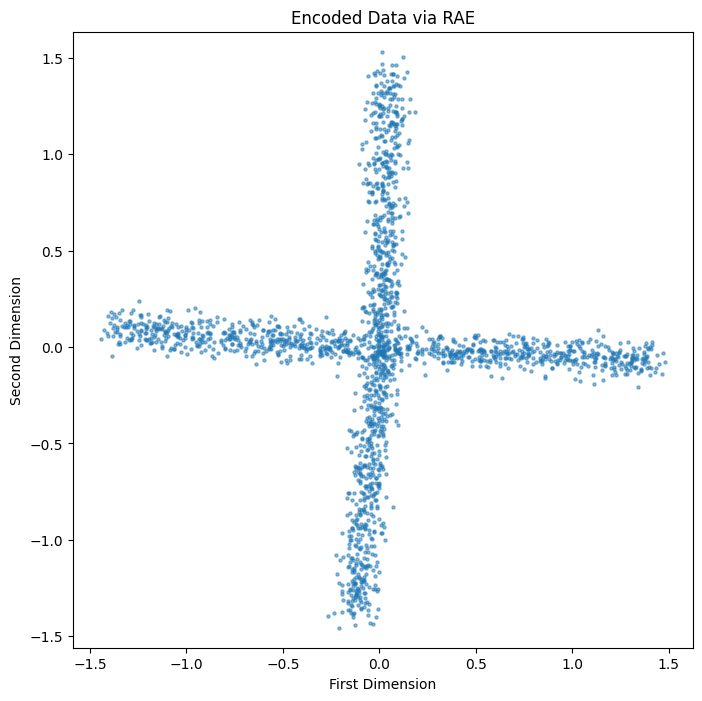

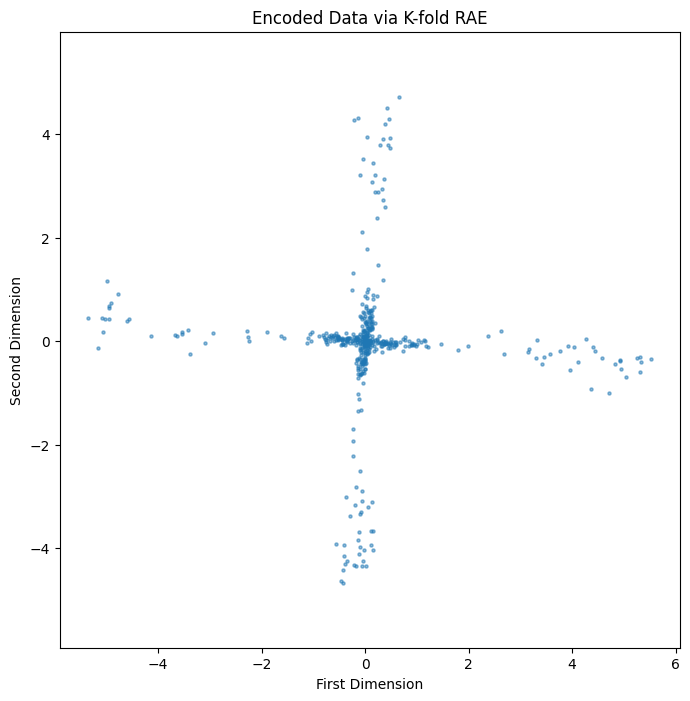

In [22]:
# encode data
with torch.no_grad():
    s_rae_encoded_data = s_rae.encode(data)
    k_rae_encoded_data = k_rae.encode(data)

# plot encoded data
plt.figure(figsize=(8, 8))
plt.scatter(s_rae_encoded_data[:, 0].numpy(), s_rae_encoded_data[:, 1].numpy(), s=5, alpha=0.5)
plt.title("Encoded Data via RAE")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(k_rae_encoded_data[:, 0].numpy(), k_rae_encoded_data[:, 1].numpy(), s=5, alpha=0.5)
plt.title("Encoded Data via K-fold RAE")
plt.xlabel("First Dimension")
plt.ylabel("Second Dimension")
plt.axis('equal')
plt.show()

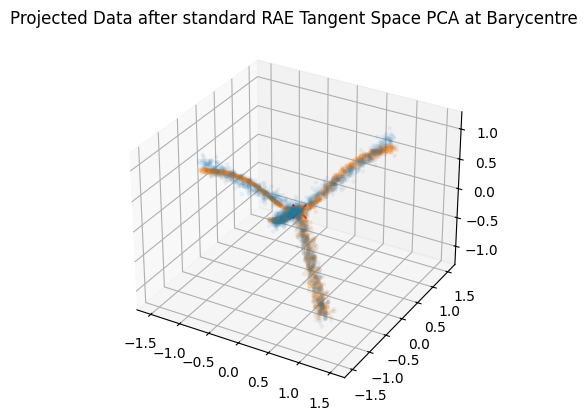

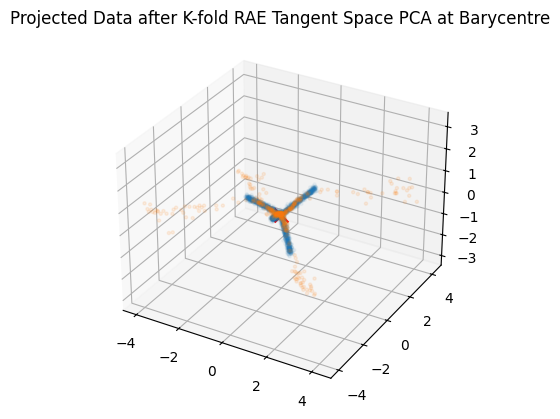

Mean reconstruction error after RAE compression: 0.07326658815145493
Mean reconstruction error after K-fold RAE compression: nan


In [23]:
# project data
with torch.no_grad():
    s_rae_projected_data = s_rae.project_on_manifold(data)
    k_rae_projected_data = k_rae.project_on_manifold(data)

# plot compressed data in 3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(s_rae_projected_data[:, 0].numpy(), s_rae_projected_data[:, 1].numpy(), s_rae_projected_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Projected Data after standard RAE Tangent Space PCA at Barycentre")
plt.axis('equal')
plt.show()

plt.figure()
ax = plt.axes(projection='3d')
# plot original data
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.05, label='Original Data')
# plot compressed data
ax.scatter(k_rae_projected_data[:, 0].numpy(), k_rae_projected_data[:, 1].numpy(), k_rae_projected_data[:, 2].numpy(), s=5, alpha=0.1)
# plot barycentre
ax.scatter(barycentre_data[0].item(), barycentre_data[1].item(), barycentre_data[2].item(), color='red', marker='x', s=100, label='Barycentre')
plt.title("Projected Data after K-fold RAE Tangent Space PCA at Barycentre")
plt.axis('equal')
plt.show()

# compute error between original data and compressed data
rel_error_s_rae_projected = (torch.norm(data - s_rae_projected_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
rel_error_k_rae_projected = (torch.norm(data - k_rae_projected_data, dim=1).mean() / torch.norm(data, dim=1).mean()).item()
print("Mean reconstruction error after RAE compression:", rel_error_s_rae_projected)
print("Mean reconstruction error after K-fold RAE compression:", rel_error_k_rae_projected)